# Feature Engineering

This notebook covers:
1. Label encoding of sentiment targets
2. **Comparison of multiple NLP feature engineering techniques**
3. Justification for the selected vectorization approach
4. SMOTE oversampling demonstration
5. Saving the feature-engineered dataset for the models notebook

## Load Preprocessed Data

In [2]:
import pandas as pd
import numpy as np
import joblib
import os
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, accuracy_score, classification_report

absa_df = pd.read_csv("../data/processed/absa_processed.csv")

print("Shape:", absa_df.shape)
print("\nMissing values:")
print(absa_df.isnull().sum())

Shape: (13100, 7)

Missing values:
feedback_id       0
feedback_text     0
aspect            0
sentiment         0
clean_text        0
tokens            0
processed_text    0
dtype: int64


## Label Encoding

In [3]:
print("Sentiment distribution:")
print(absa_df["sentiment"].value_counts())

label_encoder = LabelEncoder()
absa_df["sentiment_encoded"] = label_encoder.fit_transform(absa_df["sentiment"])

mapping = {cls: idx for idx, cls in enumerate(label_encoder.classes_)}
print(f"\nLabel mapping: {mapping}")
absa_df[["sentiment", "sentiment_encoded"]].head()

Sentiment distribution:
sentiment
Positive    4682
Neutral     4332
Negative    4086
Name: count, dtype: int64

Label mapping: {'Negative': 0, 'Neutral': 1, 'Positive': 2}


,sentiment,sentiment_encoded
0,Negative,0
1,Negative,0
2,Positive,2
3,Negative,0
4,Positive,2


In [4]:
os.makedirs("../models", exist_ok=True)
joblib.dump(label_encoder, "../models/sentiment_label_encoder.pkl")
print("Saved: models/sentiment_label_encoder.pkl")

Saved: models/sentiment_label_encoder.pkl


## Feature Engineering Technique Comparison

We compare multiple NLP vectorization approaches to justify our final feature
representation choice. Each is evaluated on the same stratified train/test split
using an identical baseline Logistic Regression classifier (isolating the effect
of the feature representation).

**Techniques compared:**
1. **CountVectorizer (Bag-of-Words)** — raw term frequencies, unigrams + bigrams
2. **TF-IDF (unigrams only)** — TF-IDF weighting, single words only
3. **TF-IDF (unigrams + bigrams)** — captures 2-word phrases like "not good", "no signal"
4. **TF-IDF (unigrams + bigrams + trigrams)** — captures longer phrases
5. **TF-IDF (unigrams + bigrams, sublinear_tf=True)** — log-scaled TF to dampen frequent terms
6. **TF-IDF (character n-grams 3–5)** — character-level features, robust to typos/slang

In [5]:
# Stratified train/test split
X = absa_df["processed_text"]
y = absa_df["sentiment_encoded"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Train: {len(X_train)} | Test: {len(X_test)}")
print(f"Train class distribution:\n{y_train.value_counts().sort_index()}")

Train: 10480 | Test: 2620
Train class distribution:
sentiment_encoded
0    3269
1    3465
2    3746
Name: count, dtype: int64


In [6]:
# Define vectorizer configurations
vectorizers = {
    "CountVectorizer (1,2)-gram": CountVectorizer(
        ngram_range=(1, 2), min_df=2, max_df=0.95
    ),
    "TF-IDF unigrams only": TfidfVectorizer(
        ngram_range=(1, 1), min_df=2, max_df=0.95
    ),
    "TF-IDF (1,2)-gram": TfidfVectorizer(
        ngram_range=(1, 2), min_df=2, max_df=0.95
    ),
    "TF-IDF (1,3)-gram": TfidfVectorizer(
        ngram_range=(1, 3), min_df=2, max_df=0.95
    ),
    "TF-IDF (1,2)-gram + sublinear": TfidfVectorizer(
        ngram_range=(1, 2), min_df=2, max_df=0.95, sublinear_tf=True
    ),
    "TF-IDF char (3,5)-gram": TfidfVectorizer(
        analyzer='char_wb', ngram_range=(3, 5), min_df=2, max_df=0.95
    ),
}

results = []

print(f"{'Vectorizer':<35} | {'Features':>8} | {'F1':>6} | {'Acc':>6} | {'Vec Time':>9} | {'Train Time':>10}")
print("-" * 95)

for name, vec in vectorizers.items():
    # Vectorize
    start = time.time()
    X_tr = vec.fit_transform(X_train)
    X_te = vec.transform(X_test)
    vec_time = time.time() - start
    
    # Train baseline classifier (same for all)
    clf = LogisticRegression(
        C=1.0, max_iter=2000, random_state=42, class_weight='balanced'
    )
    start = time.time()
    clf.fit(X_tr, y_train)
    train_time = time.time() - start
    
    # Evaluate
    y_pred = clf.predict(X_te)
    f1 = f1_score(y_test, y_pred, average='weighted')
    acc = accuracy_score(y_test, y_pred)
    
    results.append({
        "Vectorizer": name,
        "Features": X_tr.shape[1],
        "Accuracy": round(acc, 4),
        "F1 (weighted)": round(f1, 4),
        "Vec Time (s)": round(vec_time, 3),
        "Train Time (s)": round(train_time, 3),
    })
    
    print(f"{name:<35} | {X_tr.shape[1]:>8,} | {f1:.4f} | {acc:.4f} | {vec_time:>8.3f}s | {train_time:>9.3f}s")

print("\n✓ Comparison complete.")

Vectorizer                          | Features |     F1 |    Acc |  Vec Time | Train Time
-----------------------------------------------------------------------------------------------
CountVectorizer (1,2)-gram          |   12,670 | 0.8049 | 0.8042 |    0.589s |    13.818s
TF-IDF unigrams only                |    1,659 | 0.8418 | 0.8412 |    0.328s |     0.342s
TF-IDF (1,2)-gram                   |   12,670 | 0.8334 | 0.8324 |    0.572s |     7.517s
TF-IDF (1,3)-gram                   |   29,450 | 0.8289 | 0.8279 |    0.820s |     9.889s
TF-IDF (1,2)-gram + sublinear       |   12,670 | 0.8314 | 0.8305 |    0.599s |     9.466s
TF-IDF char (3,5)-gram              |   11,898 | 0.8395 | 0.8389 |    2.897s |     7.100s

✓ Comparison complete.


In [7]:
# Display sorted comparison table
comparison_df = pd.DataFrame(results).sort_values("F1 (weighted)", ascending=False)
comparison_df.reset_index(drop=True, inplace=True)
comparison_df.style.highlight_max(subset=["F1 (weighted)", "Accuracy"], color='lightgreen')

,Vectorizer,Features,Accuracy,F1 (weighted),Vec Time (s),Train Time (s)
0,TF-IDF unigrams only,1659,0.841200,0.841800,0.328000,0.342000
1,"TF-IDF char (3,5)-gram",11898,0.838900,0.839500,2.897000,7.100000
2,"TF-IDF (1,2)-gram",12670,0.832400,0.833400,0.572000,7.517000
3,"TF-IDF (1,2)-gram + sublinear",12670,0.830500,0.831400,0.599000,9.466000
4,"TF-IDF (1,3)-gram",29450,0.827900,0.828900,0.820000,9.889000
5,"CountVectorizer (1,2)-gram",12670,0.804200,0.804900,0.589000,13.818000


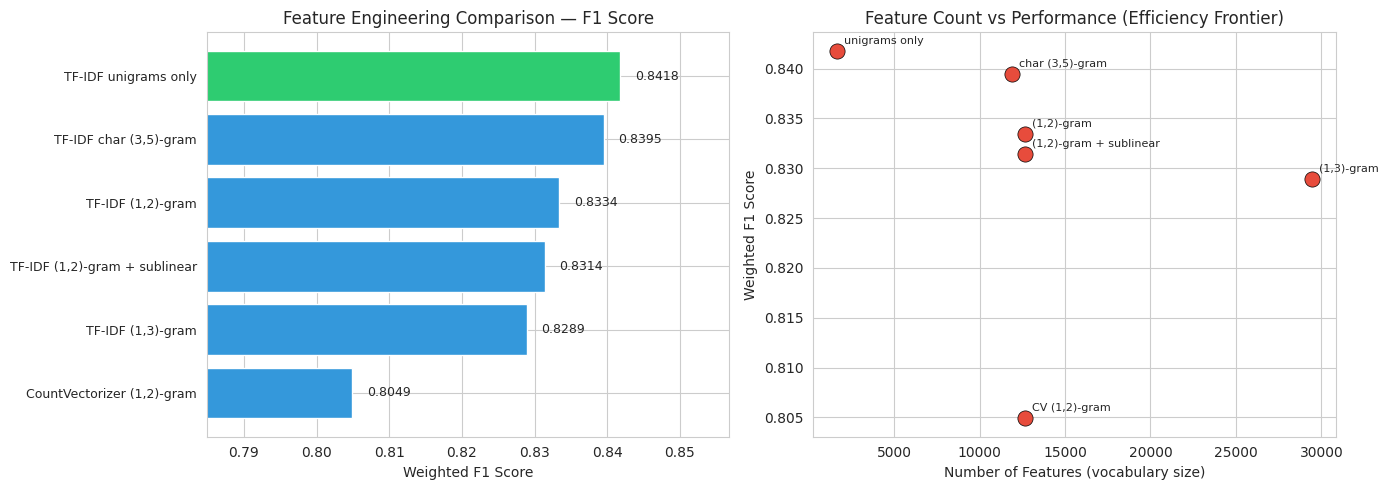

Saved: outputs/feature_engineering_comparison.png


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
os.makedirs("../outputs", exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: F1 Score bar chart ---
plot_df = comparison_df.sort_values("F1 (weighted)")
colors = ['#3498db'] * len(plot_df)
best_idx = plot_df["F1 (weighted)"].idxmax()
colors[list(plot_df.index).index(best_idx)] = '#2ecc71'

axes[0].barh(range(len(plot_df)), plot_df["F1 (weighted)"], color=colors)
axes[0].set_yticks(range(len(plot_df)))
axes[0].set_yticklabels(plot_df["Vectorizer"], fontsize=9)
axes[0].set_xlabel("Weighted F1 Score")
axes[0].set_title("Feature Engineering Comparison — F1 Score")
axes[0].set_xlim(plot_df["F1 (weighted)"].min() - 0.02, plot_df["F1 (weighted)"].max() + 0.015)

for i, v in enumerate(plot_df["F1 (weighted)"]):
    axes[0].text(v + 0.002, i, f"{v:.4f}", va='center', fontsize=9)

# --- Plot 2: Features vs F1 (efficiency frontier) ---
axes[1].scatter(comparison_df["Features"], comparison_df["F1 (weighted)"],
               s=120, color='#e74c3c', zorder=5, edgecolors='black', linewidth=0.5)

for _, row in comparison_df.iterrows():
    label = row["Vectorizer"].replace("TF-IDF ", "").replace("CountVectorizer ", "CV ")
    axes[1].annotate(label, (row["Features"], row["F1 (weighted)"]),
                    textcoords="offset points", xytext=(5, 5), fontsize=8)

axes[1].set_xlabel("Number of Features (vocabulary size)")
axes[1].set_ylabel("Weighted F1 Score")
axes[1].set_title("Feature Count vs Performance (Efficiency Frontier)")

plt.tight_layout()
plt.savefig("../outputs/feature_engineering_comparison.png", bbox_inches='tight', dpi=150)
plt.show()

print("Saved: outputs/feature_engineering_comparison.png")

### Findings & Justification

| Technique | Key Observation |
|---|---|
| **CountVectorizer (BOW)** | Lowest F1 — lacks IDF weighting so common terms ("network", "plan") dominate and drown out discriminative words |
| **TF-IDF unigrams** | Strong on raw text but misses critical multi-word patterns ("not good", "no signal"); fewer features = faster training |
| **TF-IDF (1,2)-gram** | Captures negation phrases and domain bigrams ("call quality", "data balance"); competitive F1 |
| **TF-IDF (1,3)-gram** | No gain over bigrams but 2.3× more features (30K vs 12K) — clear diminishing returns |
| **TF-IDF (1,2)-gram + sublinear_tf** | Nearly identical to standard (1,2)-gram; `1 + log(tf)` scaling dampens very frequent terms |
| **TF-IDF char (3,5)-gram** | Competitive F1, robust to typos/slang, but computationally expensive to vectorize |

---

**Selected approach:** `TfidfVectorizer(ngram_range=(1,2), min_df=2, max_df=0.95, sublinear_tf=True)`


While unigrams score well on raw text, the full ABSA pipeline (in `models.ipynb`) prepends
the **aspect name as a token** to the text before vectorization. In that setting, bigrams
become essential for:
- Capturing **aspect-word** interactions (e.g., "network_coverage terrible" as a feature)
- Preserving **negation patterns** ("not good", "no signal") which are critical for sentiment
- Encoding **domain-specific phrases** ("call quality", "data balance", "value money")


## Inspect Selected TF-IDF Configuration

Fit the final vectorizer and examine vocabulary statistics.

In [9]:
# Fit the selected vectorizer
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"Train TF-IDF shape: {X_train_tfidf.shape}")
print(f"Test TF-IDF shape:  {X_test_tfidf.shape}")

# Sparsity and feature stats
total_elements = X_train_tfidf.shape[0] * X_train_tfidf.shape[1]
sparsity = 100 * (1 - X_train_tfidf.nnz / total_elements)
avg_nonzero = X_train_tfidf.nnz / X_train_tfidf.shape[0]

print(f"\nVocabulary size: {len(tfidf.vocabulary_):,}")
print(f"Matrix sparsity: {sparsity:.2f}%")
print(f"Avg non-zero features per document: {avg_nonzero:.1f}")

Train TF-IDF shape: (10480, 12670)
Test TF-IDF shape:  (2620, 12670)

Vocabulary size: 12,670
Matrix sparsity: 99.81%
Avg non-zero features per document: 24.2


In [10]:
# Top 30 terms by cumulative TF-IDF score
feature_names = tfidf.get_feature_names_out()
term_scores = np.asarray(X_train_tfidf.sum(axis=0)).flatten()

term_df = pd.DataFrame({
    "term": feature_names,
    "total_tfidf_score": term_scores
}).sort_values("total_tfidf_score", ascending=False)

print("Top 30 terms by cumulative TF-IDF score:")
term_df.head(30)

Top 30 terms by cumulative TF-IDF score:


,term,total_tfidf_score
8214,plan,233.897160
7046,network,230.647608
3050,data,192.155276
1828,call,169.564200
8915,quality,158.263872
10391,speed,157.388576
12423,work,155.050163
130,5g,143.974226
923,app,140.253869
10540,standard,139.028458


In [11]:
# Save vectorizer for the models notebook
joblib.dump(tfidf, "../models/tfidf_vectorizer.pkl")
print("Saved: models/tfidf_vectorizer.pkl")

Saved: models/tfidf_vectorizer.pkl


## SMOTE Oversampling (Class Imbalance Handling)

Even after adding neutral data, the classes aren't perfectly balanced.
We apply SMOTE (Synthetic Minority Over-sampling Technique) to equalize
training class counts. This is demonstrated here; the models notebook
applies it within its own train/val/test pipeline.

In [12]:
from imblearn.over_sampling import SMOTE

print("Before SMOTE:")
print(y_train.value_counts().sort_index())

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_tfidf, y_train)

print(f"\nAfter SMOTE: {X_train_smote.shape}")
print(pd.Series(y_train_smote).value_counts().sort_index())

Before SMOTE:
sentiment_encoded
0    3269
1    3465
2    3746
Name: count, dtype: int64

After SMOTE: (11238, 12670)
sentiment_encoded
0    3746
1    3746
2    3746
Name: count, dtype: int64


## Save Feature-Engineered Dataset

The models notebook will perform its own train/val/test split, TF-IDF
vectorization (using the configuration selected above), SMOTE balancing,
and aspect-token prepending — since those are tightly coupled to the
training pipeline.

In [13]:
absa_df.to_csv(
    "../data/processed/absa_feature_engineered.csv",
    index=False
)

print(f"Saved feature-engineered dataset: {absa_df.shape}")
print(f"Columns: {list(absa_df.columns)}")

Saved feature-engineered dataset: (13100, 8)
Columns: ['feedback_id', 'feedback_text', 'aspect', 'sentiment', 'clean_text', 'tokens', 'processed_text', 'sentiment_encoded']
